# HƯỚNG DẪN 7A: XÂY DỰNG ĐẶC TRƯNG

----

## Những bộ biến đổi
Những nhiệm vụ này thì sử dụng **bộ biến đổi**

"Biến đổi" của sklearn được sử dụng cho mục đích này, các phương pháp chính là:
- transformer.fit()
- transformer.transform()
- transformer.fit_transform()

Lưu ý rằng việc phân tích và điều chỉnh (huấn luyện) chỉ dựa trên tập dữ liệu huấn luyện. Sau đó, các phép biến đổi đã học được sẽ được áp dụng cho tập dữ liệu thử nghiệm.

In [28]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Tải lên tập dữ liệu

In [29]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
# Tách biến mục tiêu
X=df[df.columns[1:-1]] # đọc "-1" là số cuối cùng
y=df[df.columns[-1]]

In [31]:
# Hiển thị số lượng trường hợp của mỗi lớp
y.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [32]:
# tách dữ liệu
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42, stratify=y)

In [33]:
# Kiểm tra trước khi chuẩn hóa
X_train.head()

,sepal_width,petal_length,petal_width
98,2.5,3.0,1.1
68,2.2,4.5,1.5
19,3.8,1.5,0.3
143,3.2,5.9,2.3
99,2.8,4.1,1.3


## **PCA**

### Chuẩn hóa dữ liệu

PCA bị ảnh hưởng bởi thang đo: bạn nên gán cho mỗi đặc trưng trong dữ liệu của mình một thang đo tương tự (trung bình = 0 và phương sai = 1) trước khi áp dụng PCA.
Chúng ta sẽ sử dụng `StandardScaler` để chuẩn hóa các đặc trưng trong tập dữ liệu.

In [34]:
# Bây giờ hãy áp dụng 1-1 "StandardScaler" bộ biến đổi
# 1) import the module
from sklearn.preprocessing import StandardScaler

# 2) Định nghĩa mô hình
scaler = StandardScaler()

# 3) Phù hợp với mô hình
scaler.fit(X_train)

# 4) Biến đổi dữ liệu
X_train_ss = scaler.transform(X_train)

# Lưu ý 3 và 4 có thể được kết hợp như này:
# X_train_ss = SS_fit_transform(X_train)

### Run PCA

In [35]:
# Bây giờ hãy hiển thị pca
# Những bước tương tự như scale transformer
# 1) import the module
from sklearn.decomposition import PCA
# 2) Định nghĩa mô hình
pca = PCA(n_components=2) #n_components có nghĩa là phép biến đổi pca xây dựng nhiều tính năng này
# 3) Phù hợp với mô hình
pca.fit(X_train_ss)
# 4) biến đổi dữ liệu
pca_train = pca.transform(X_train_ss)
# 3 và 4 có thể được kết hợp
# pca_train = pca.fit_transform(X_train_ss)
# in output, ma trận nào chỉ có 2 đặc trưng
pca_train[:10, :]
# ALT: plt.scatter(pca_train[:,0], pca_train[:,1])

array([[ 0.09953905, -1.27195338],
       [ 1.24517682, -1.511778  ],
       [-2.23995982,  0.82850939],
       [ 1.56980436,  1.02026044],
       [ 0.41457825, -0.43457392],
       [ 1.48337778,  0.51976305],
       [-1.80491446, -0.66531921],
       [-2.2865126 ,  0.80241998],
       [-1.58636569, -1.04325442],
       [ 1.57485976,  0.53649337]])

### Trực quan kết quả

possible if it's 2d

<Axes: xlabel='pc1', ylabel='pc2'>

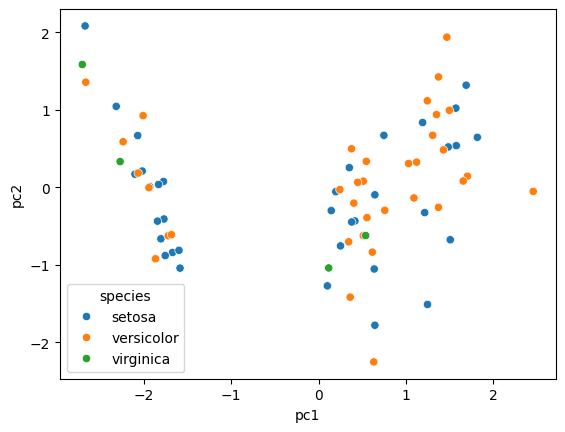

In [36]:
# Định dạng và trực quan dữ liệu huấn luyện đã biến đổi
df_pca_train = pd.DataFrame(data= pca_train, columns= ['pc1', 'pc2'])
df_pca_train['species'] = y_train
sns.scatterplot(x = 'pc1', y = 'pc2', hue = df_pca_train['species'], data= df_pca_train)

### Biến đổi dữ liệu test

lưu ý: Ở đây chúng tôi chỉ áp dụng các bộ biến đổi đã học để biến đổi dữ liệu thử nghiệm, KHÔNG sử dụng phép phù hợp

In [37]:
# 1- Đầu tiên, áp dụng bộ chia tỷ lệ đã được xây dựng dựa trên dữ liệu đào tạo để chia tỷ lệ dữ liệu thử nghiệm
X_test_ss = scaler.transform(X_test)
# 2- Thứ hai, áp dụng biến đổi pca đã được xây dựng dựa trên dữ liệu đã được đào tạo cho dữ liệu thử nghiệm
pca_test = pca.transform(X_test_ss)

### Phân loại

In [38]:
# Thực hiện phân loại dựa vào dữ liệu gốc
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(random_state=0)
#classifier = SVC()
classifier.fit(X_train, y_train)
score = accuracy_score(classifier.predict(X_test), y_test)
print('Accuracy trước khi biến đổi = {:.2f}'.format(score))

Accuracy trước khi biến đổi = 0.91


## ICA

Những bước này thì tương tự như bộ biến đổi scaler và PCA

Trên thực tế, có một số phương pháp ICA. Chúng ta sẽ sử dụng thuật toán `Fast ICA` của sklearn.

In [39]:
from sklearn.decomposition import FastICA
ica = FastICA(n_components=2)
ica_train = ica.fit_transform(X_train_ss) # nb. chúng ta đã thực hiện chia tỉ lệ ở trên

<Axes: xlabel='ic1', ylabel='ic2'>

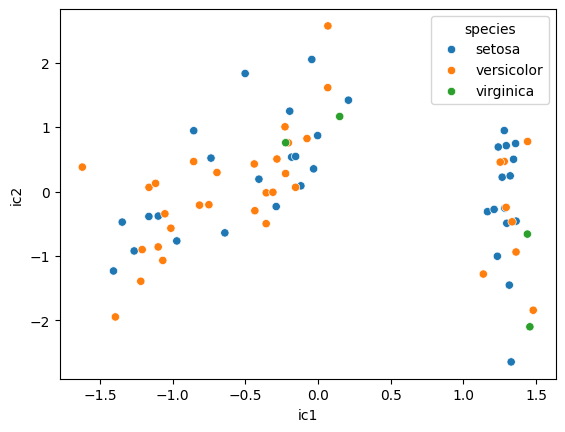

In [40]:
# Trực quan
df_ica_train = pd.DataFrame(data=ica_train, columns=['ic1', 'ic2'])
df_ica_train['species'] = y_train
sns.scatterplot(x='ic1', y='ic2', hue = df_ica_train['species'], data=df_ica_train)

In [41]:
# Thực hiện phân loại bằng cách sử dụng dữ liệu chuyển đổi dựa trên ica
# Biến đổi dữ liệu thử nghiệm sử dụng ica
classifier.fit(ica_train, y_train)
ica_test = ica.transform(X_test_ss)
score = accuracy_score(classifier.predict(ica_test), y_test)
print('Accuracy sau khi biến đổi ICA = {:.2f}'.format(score))

Accuracy sau khi biến đổi ICA = 0.96


## GP transformers

In [42]:
# Có thể cần phải cài đặt gói lập trình di truyền (gp)
# Vì gói này không hoạt động khi biến mục tiêu là chuỗi, nên bộ mã hóa được sử dụng để chuyển đổi nó
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoded = le.fit_transform(y_train)
label_encoded

array([1, 1, 0, 2, 1, 2, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 0, 0, 2, 1, 0, 2,
       2, 2, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 2, 2, 0, 2, 0, 2, 0,
       2, 1, 0, 2, 1, 2, 1, 0, 1, 2, 1, 2, 0, 1, 0, 1, 1, 1, 2, 1, 1, 2,
       2, 0, 2, 1, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2,
       2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 0, 1, 0])

In [43]:
# Bây giờ hãy áp dụng chương trình mã di truyền
# Những bước tương tự như bộ chuyển đổi scale, pca và ica
from gplearn.genetic import SymbolicTransformer
from sklearn.base import BaseEstimator
from sklearn.utils._tags import _safe_tags

# Ghi đè hàm __sklearn_tags__ để tương thích sklearn>=1.6
def _patched_sklearn_tags(self):
    # Lấy tags mặc định từ BaseEstimator thay vì chính self (tránh đệ quy)
    return _safe_tags(BaseEstimator())

# Gán lại cho class SymbolicTransformer
SymbolicTransformer.__sklearn_tags__ = _patched_sklearn_tags

# Tiếp tục như bình thường
gp = SymbolicTransformer(n_components=2)
gp.fit(X_train_ss, label_encoded)
gp_train = gp.transform(X_train_ss)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


<Axes: xlabel='gp1', ylabel='gp2'>

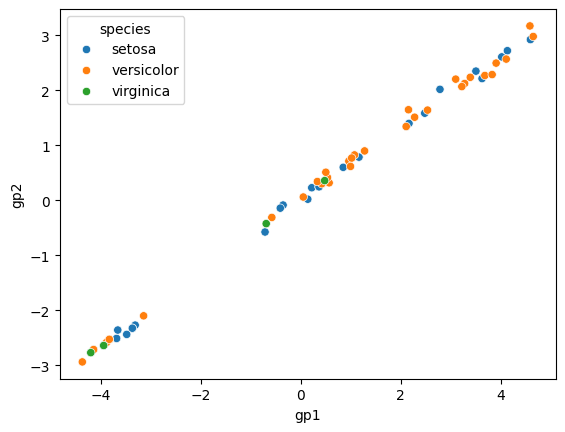

In [44]:
# Trực quan dử dụng gp-based dữ liệu đã biến đổi
df_gp_train = pd.DataFrame(data = gp_train, columns = ['gp1', 'gp2'])
df_gp_train['species'] = y_train
sns.scatterplot(x = 'gp1', y = 'gp2', hue = df_gp_train['species'], data = df_gp_train)

In [45]:
# Biến đổi dữ liệu thử nghiệm sử dụng gp
# Sau đó, thực hiện phân loại bằng cách sử dụng dữ liệu chuyển đổi dựa trên ica
gp_test = gp.transform(X_test_ss)
df_gp_test = pd.DataFrame(data = gp_test, columns = ['gp1', 'gp2'])
df_gp_test['species'] = y_test
classifier.fit(gp_train, y_train)
accuracy_score(classifier.predict(gp_test), y_test)

0.9333333333333333